In [1]:
import pandas as pd
import numpy as np
import sys
from pathlib import Path

def find_project_root(start: Path, marker: str = "src") -> Path:
    current = start.resolve()
    for path in [current, *current.parents]:
        if (path / marker).exists():
            return path
    raise RuntimeError(f"Could not find project root containing '{marker}'")

PROJECT_ROOT = find_project_root(Path.cwd())

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)

PROJECT_ROOT = /Users/rawls/quant-lab


In [2]:
from src.utils.metrics import sharpe_ratio, max_drawdown
from src.features.returns import make_forward_returns
from src.portfolio.construction import equal_weight_long_short
from src.backtest.engine import backtest_cross_sectional_strategy

import importlib
import src.portfolio.construction as pc

importlib.reload(pc)

from src.portfolio.construction import build_daily_weights_from_panel
print("Imports working") 

Imports working


In [3]:
import pandas as pd

v1_path = PROJECT_ROOT / "data" / "processed" / "v1.csv"
v2_path = PROJECT_ROOT / "data" / "processed" / "v2.csv"

print(v1_path)
print(v2_path)
print(v1_path.exists(), v2_path.exists())

df_v1 = pd.read_csv(v1_path)
df_v2 = pd.read_csv(v2_path)

/Users/rawls/quant-lab/data/processed/v1.csv
/Users/rawls/quant-lab/data/processed/v2.csv
True True


**Align both Datasets**

In [4]:
df_v1_clean = df_v1[["Date", "Ticker", "fwd_ret_5", "pred_flipped"]].copy()
df_v1_clean = df_v1_clean.rename(columns={"pred_flipped": "signal_v1"})

df_v2_clean = df_v2[["Date", "Ticker", "pred"]].copy()
df_v2_clean = df_v2_clean.rename(columns={"pred": "signal_v2"})

df_combined = df_v1_clean.merge(
    df_v2_clean[["Date", "Ticker", "signal_v2"]],
    on=["Date", "Ticker"],
    how="inner"
)

In [5]:
print(df_combined.columns)
print(df_combined[["Date", "Ticker", "signal_v1", "signal_v2", "fwd_ret_5"]].head())
print(df_combined.shape)

Index(['Date', 'Ticker', 'fwd_ret_5', 'signal_v1', 'signal_v2'], dtype='str')
         Date Ticker  signal_v1  signal_v2  fwd_ret_5
0  2016-01-04   AAPL  -0.002165   0.001551  -0.064857
1  2016-01-04   AMZN  -0.005828   0.006377  -0.030220
2  2016-01-04    BAC  -0.006820   0.006253  -0.068093
3  2016-01-04   COST  -0.004952   0.004944  -0.030191
4  2016-01-04    CVX  -0.006027   0.005406  -0.090928
(51160, 5)


**Standardize Both Signals**

In [6]:
df_combined["signal_v1_z"] = df_combined.groupby("Date")["signal_v1"].transform(
    lambda x: (x - x.mean()) / x.std()
)

df_combined["signal_v2_z"] = df_combined.groupby("Date")["signal_v2"].transform(
    lambda x: (x - x.mean()) / x.std()
)

**Combine Signals**

In [7]:
df_combined["combined_signal"] = (
    df_combined["signal_v1_z"] + df_combined["signal_v2_z"]
)

**Equal Weighted Portfolio**

In [8]:
weights_combined = build_daily_weights_from_panel(
    df_combined,
    signal_col="combined_signal",
    date_col="Date",
    asset_col="Ticker"
)

**Backtest**

In [9]:
port_combined = backtest_cross_sectional_strategy(
    weights_combined,
    df_combined,
    return_col="fwd_ret_5"
)

In [10]:
print("Combined Sharpe:", sharpe_ratio(port_combined["portfolio_return"]))
print("Combined MDD:", max_drawdown(port_combined["equity_curve"]))

Combined Sharpe: 1.115019358929923
Combined MDD: -0.7116861329009108


Combining v1 and v2 signals slightly reduces Sharpe (~1.19 → ~1.12) but significantly improves drawdown (~-90% → ~-71%), indicating that the signals are complementary and provide better stability, though the strategy still requires improved portfolio construction to be tradable.

**Signal Weighted Portfolio**

In [11]:
weights_signal_uncapped = build_daily_weights_from_panel(
    df_combined,
    signal_col="combined_signal",
    date_col="Date",
    asset_col="Ticker",
    method="signal",
    max_weight=None
)

In [12]:
port_combined_signal = backtest_cross_sectional_strategy(
    weights_signal_uncapped,
    df_combined,
    return_col="fwd_ret_5"
)

print("Signal-weighted Sharpe:", sharpe_ratio(port_combined_signal["portfolio_return"]))
print("Signal-weighted MDD:", max_drawdown(port_combined_signal["equity_curve"]))

Signal-weighted Sharpe: 1.2340829646182438
Signal-weighted MDD: -0.7941628405133125


Moving from equal-weight to signal-weighted allocation improved Sharpe (~1.12 to ~1.23), confirming that stronger signals deserve larger weights, but drawdown worsened (~-71% to ~-79%), indicating that additional risk controls are needed to limit concentration.

**Weight Capped (Position Capping)**

In [13]:
weights_signal_capped = build_daily_weights_from_panel(
    df_combined,
    signal_col="combined_signal",
    method="signal",
    max_weight=0.10
)

port_capped = backtest_cross_sectional_strategy(
    weights_signal_capped,
    df_combined,
    return_col="fwd_ret_5"
)

print("Capped Sharpe:", sharpe_ratio(port_capped["portfolio_return"]))
print("Capped MDD:", max_drawdown(port_capped["equity_curve"]))

Capped Sharpe: 1.2158364119820746
Capped MDD: -0.7448535361880926


In [14]:
weights_signal_uncapped.groupby("Date")["weight"].sum().describe()
weights_signal_uncapped.groupby("Date")["weight"].apply(lambda x: x.abs().sum()).describe()

weights_signal_capped.groupby("Date")["weight"].sum().describe()
weights_signal_capped.groupby("Date")["weight"].apply(lambda x: x.abs().sum()).describe()
weights_signal_capped["weight"].abs().max()

np.float64(0.33176938030190434)

Applying position caps slightly reduced Sharpe (~1.23 to ~1.22) but meaningfully improved drawdown (~-79% to ~-74%), confirming that limiting concentration risk leads to a more stable and tradable strategy without materially degrading alpha.

**Integrating Project 2 - volatility regime**

In [15]:
df_vol = pd.read_csv(
    PROJECT_ROOT / "data" / "processed" / "vol_regime_calibrated_oof.csv"
)

df_vol["Date"] = pd.to_datetime(df_vol["Date"])
df_combined["Date"] = pd.to_datetime(df_combined["Date"])

print(df_vol.head())

        Date  p_high_vol_calibrated
0 2014-01-23               0.057369
1 2014-01-24               0.063115
2 2014-01-27               0.063058
3 2014-01-28               0.064146
4 2014-01-29               0.063462


In [16]:
df_vol = df_vol.sort_values("Date").copy()
# position sizing signal/ how much capital you deploy
df_vol["exposure"] = 1 - df_vol["p_high_vol_calibrated"]

In [17]:
df_vol["exposure_lag1"] = df_vol["exposure"].shift(1)  #lagging to avoid look ahead bias

**Merging to the Alpha Dataset**

In [18]:
df_combined = df_combined.merge(
    df_vol[["Date", "exposure_lag1"]],
    on="Date",
    how="left"
)

print(df_combined[["Date", "Ticker", "combined_signal", "exposure_lag1"]].head())

        Date Ticker  combined_signal  exposure_lag1
0 2016-01-04   AAPL        -0.089663       0.859773
1 2016-01-04   AMZN         0.589947       0.859773
2 2016-01-04    BAC        -0.258660       0.859773
3 2016-01-04   COST         0.225735       0.859773
4 2016-01-04    CVX        -0.263045       0.859773


**Build Weights**

In [19]:
weights_scaled = build_daily_weights_from_panel(
    df_combined,
    signal_col="combined_signal",
    date_col="Date",
    asset_col="Ticker",
    method="signal",
    max_weight=0.10
)

**Exposure Scaling**

In [20]:
weights_scaled = weights_scaled.merge(
    df_combined[["Date", "exposure_lag1"]].drop_duplicates(),
    on="Date",
    how="left")

#fallback for early NaNs
weights_scaled["exposure_lag1"] = weights_scaled["exposure_lag1"].fillna(1.0)

weights_scaled["weight"] = (
    weights_scaled["weight"] * weights_scaled["exposure_lag1"]
)

**Sanity Check**

In [21]:
print(weights_scaled.groupby("Date")["weight"].sum().describe())
print(weights_scaled.groupby("Date")["weight"].apply(lambda x: x.abs().sum()).describe())

count    2.558000e+03
mean    -1.159647e-18
std      5.775836e-17
min     -1.804112e-16
25%     -4.163336e-17
50%      0.000000e+00
75%      2.775558e-17
max      2.220446e-16
Name: weight, dtype: float64
count    2558.000000
mean        0.818333
std         0.145482
min         0.178844
25%         0.724097
50%         0.847996
75%         0.928753
max         1.000000
Name: weight, dtype: float64


**Backtest**

In [22]:
port_scaled = backtest_cross_sectional_strategy(
    weights_scaled,
    df_combined,
    return_col="fwd_ret_5"
)

print("Scaled Sharpe:", sharpe_ratio(port_scaled["portfolio_return"]))
print("Scaled MDD:", max_drawdown(port_scaled["equity_curve"]))

Scaled Sharpe: 1.106746216246181
Scaled MDD: -0.7051127072331238


**Exposure Tuning**

In [23]:
df_vol["exposure"] = 1 - df_vol["p_high_vol_calibrated"]

In [24]:
import numpy as np

p = df_vol["p_high_vol_calibrated"]

df_vol["exp_linear"] = 1 - p  # Linear exposure
df_vol["exp_sqrt"] = np.sqrt(1 - p)   # Softer
df_vol["exp_floor_30"] = np.maximum(0.3, 1 - p)   # With Floor - exposure is the biggest amoung 0.3 or 1-p
df_vol["exp_threshold"] = np.where(
    p > 0.8, 0.2,
    np.where(p > 0.6, 0.6, 1.0)     
)   # Threshold rule

print(df_vol[["Date", "p_high_vol_calibrated", "exp_linear", "exp_sqrt", "exp_floor_30", "exp_threshold"]].head())

        Date  p_high_vol_calibrated  exp_linear  exp_sqrt  exp_floor_30  \
0 2014-01-23               0.057369    0.942631  0.970892      0.942631   
1 2014-01-24               0.063115    0.936885  0.967928      0.936885   
2 2014-01-27               0.063058    0.936942  0.967958      0.936942   
3 2014-01-28               0.064146    0.935854  0.967395      0.935854   
4 2014-01-29               0.063462    0.936538  0.967749      0.936538   

   exp_threshold  
0            1.0  
1            1.0  
2            1.0  
3            1.0  
4            1.0  


In [25]:
for col in ["exp_linear", "exp_sqrt", "exp_floor_30", "exp_threshold"]:
    df_vol[f"{col}_lag1"] = df_vol[col].shift(1)

In [26]:
merge_cols = [
    "Date",
    "exp_linear_lag1",
    "exp_sqrt_lag1",
    "exp_floor_30_lag1",
    "exp_threshold_lag1",
]

df_combined = df_combined.drop(
    columns=[c for c in merge_cols if c in df_combined.columns and c != "Date"],
    errors="ignore"
)

df_combined = df_combined.merge(
    df_vol[merge_cols],
    on="Date",
    how="left"
)

In [27]:
weights_base = build_daily_weights_from_panel(
    df_combined,
    signal_col="combined_signal",
    date_col="Date",
    asset_col="Ticker",
    method="signal",
    max_weight=0.10
)

In [28]:
def run_scaled_backtest(weights_base, df_combined, exposure_col):
    w = weights_base.merge(
        df_combined[["Date", exposure_col]].drop_duplicates(),
        on="Date",
        how="left"
    ).copy()

    w[exposure_col] = w[exposure_col].fillna(1.0)
    w["weight"] = w["weight"] * w[exposure_col]

    port = backtest_cross_sectional_strategy(
        w,
        df_combined,
        return_col="fwd_ret_5"
    )

    return {
        "exposure_col": exposure_col,
        "avg_gross_exposure": w.groupby("Date")["weight"].apply(lambda x: x.abs().sum()).mean(),
        "sharpe": sharpe_ratio(port["portfolio_return"]),
        "mdd": max_drawdown(port["equity_curve"]),
    }

In [29]:
results = []

for col in [
    "exp_linear_lag1",
    "exp_sqrt_lag1",
    "exp_floor_30_lag1",
    "exp_threshold_lag1",
]:
    results.append(run_scaled_backtest(weights_base, df_combined, col))

results_df = pd.DataFrame(results)
print(results_df)

         exposure_col  avg_gross_exposure    sharpe       mdd
0     exp_linear_lag1            0.818333  1.106746 -0.705113
1       exp_sqrt_lag1            0.900278  1.159820 -0.725082
2   exp_floor_30_lag1            0.819264  1.122548 -0.705113
3  exp_threshold_lag1            0.990149  1.159794 -0.744854


Introducing a minimum exposure floor of 30% slightly improved Sharpe without increasing drawdown, indicating that the volatility scaling was occasionally too conservative and benefited from preventing excessive de-risking.

**Exponent Tuning / Curvature Tuning**

In [30]:
import numpy as np
import pandas as pd

# curvature is how fast exposure drops as p increases
# choose exponents to test
alphas = [0.3, 0.5, 0.7, 1.0, 1.2]

# start from vol df already loaded
df_vol = df_vol.sort_values("Date").copy()

p = df_vol["p_high_vol_calibrated"]

# create exponent-based exposure columns
for a in alphas:
    col = f"exp_pow_{str(a).replace('.', '_')}"
    df_vol[col] = (1 - p) ** a
    df_vol[f"{col}_lag1"] = df_vol[col].shift(1)

print(
    df_vol[
        ["Date", "p_high_vol_calibrated"] +
        [f"exp_pow_{str(a).replace('.', '_')}" for a in alphas]
    ].head()
)

        Date  p_high_vol_calibrated  exp_pow_0_3  exp_pow_0_5  exp_pow_0_7  \
0 2014-01-23               0.057369     0.982432     0.970892     0.959488   
1 2014-01-24               0.063115     0.980632     0.967928     0.955389   
2 2014-01-27               0.063058     0.980650     0.967958     0.955430   
3 2014-01-28               0.064146     0.980308     0.967395     0.954653   
4 2014-01-29               0.063462     0.980523     0.967749     0.955142   

   exp_pow_1_0  exp_pow_1_2  
0     0.942631     0.931559  
1     0.936885     0.924748  
2     0.936942     0.924816  
3     0.935854     0.923527  
4     0.936538     0.924337  


In [31]:
pow_cols = ["Date"] + [f"exp_pow_{str(a).replace('.', '_')}_lag1" for a in alphas]

# avoid duplicate-column issues if rerunning
df_combined = df_combined.drop(
    columns=[c for c in pow_cols if c in df_combined.columns and c != "Date"],
    errors="ignore"
)

df_combined = df_combined.merge(
    df_vol[pow_cols],
    on="Date",
    how="left"
)

In [32]:
weights_base = build_daily_weights_from_panel(
    df_combined,
    signal_col="combined_signal",
    date_col="Date",
    asset_col="Ticker",
    method="signal",
    max_weight=0.10
)

In [33]:
def run_scaled_backtest(weights_base, df_combined, exposure_col):
    w = weights_base.merge(
        df_combined[["Date", exposure_col]].drop_duplicates(),
        on="Date",
        how="left"
    ).copy()

    w[exposure_col] = w[exposure_col].fillna(1.0)
    w["weight"] = w["weight"] * w[exposure_col]

    port = backtest_cross_sectional_strategy(
        w,
        df_combined,
        return_col="fwd_ret_5"
    )

    return {
        "exposure_col": exposure_col,
        "alpha": exposure_col.replace("exp_pow_", "").replace("_lag1", "").replace("_", "."),
        "avg_gross_exposure": w.groupby("Date")["weight"].apply(lambda x: x.abs().sum()).mean(),
        "sharpe": sharpe_ratio(port["portfolio_return"]),
        "mdd": max_drawdown(port["equity_curve"]),
    }

In [34]:
results_pow = []

for a in alphas:
    col = f"exp_pow_{str(a).replace('.', '_')}_lag1"
    results_pow.append(run_scaled_backtest(weights_base, df_combined, col))

results_pow_df = pd.DataFrame(results_pow)
print(results_pow_df.sort_values("sharpe", ascending=False))

       exposure_col alpha  avg_gross_exposure    sharpe       mdd
0  exp_pow_0_3_lag1   0.3            0.937690  1.182683 -0.733018
1  exp_pow_0_5_lag1   0.5            0.900278  1.159820 -0.725082
2  exp_pow_0_7_lag1   0.7            0.865677  1.137726 -0.717114
3  exp_pow_1_0_lag1   1.0            0.818333  1.106746 -0.705113
4  exp_pow_1_2_lag1   1.2            0.789424  1.087485 -0.697085


Exponent tuning revealed a clear risk-return tradeoff, with α ≈ 0.7 providing the best balance by improving Sharpe over the linear baseline while only slightly increasing drawdown, making it the most practical exposure scaling choice.

**Combining Signal Strength and Volatility**

In [35]:
# Volatility adjustment

alpha = 0.7
df_col = df_vol.sort_values("Date").copy()
df_vol["vol_adj_pow_07"] = (1 - df_vol["p_high_vol_calibrated"]) ** alpha
df_vol["vol_adj_pow_07_lag1"] = df_vol["vol_adj_pow_07"].shift(1)

df_combined = df_combined.merge(
    df_vol[["Date", "vol_adj_pow_07_lag1"]],
    on="Date",
    how="left"
)

df_combined["signal_vol_adj"] = (
    df_combined["combined_signal"] * df_combined["vol_adj_pow_07_lag1"].fillna(1.0)
)



In [36]:
weights_vol_signal = build_daily_weights_from_panel(
    df_combined,
    signal_col="signal_vol_adj",
    date_col="Date",
    asset_col="Ticker",
    method="signal",
    max_weight=0.10
)

port_vol_signal = backtest_cross_sectional_strategy(
    weights_vol_signal,
    df_combined,
    return_col="fwd_ret_5"
)

print("Vol-adjusted Signal Sharpe:", sharpe_ratio(port_vol_signal["portfolio_return"]))
print("Vol-adjusted Signal MDD", max_drawdown(port_vol_signal["equity_curve"]))

Vol-adjusted Signal Sharpe: 1.2158364119820744
Vol-adjusted Signal MDD -0.7448535361880926


Integrating volatility into the signal improves Sharpe but weakens drawdown control because the portfolio remains fully invested, highlighting that signal scaling and exposure scaling serve complementary roles.

**Hybrid weight model**

In [37]:
alpha = 0.7

df_vol["vol_adj-pow_07"] = (1 - df_vol["p_high_vol_calibrated"]) ** alpha
df_vol["vol_adj_pow_07_lag1"] = df_vol["vol_adj_pow_07"].shift(1)

# portfolio-level exposure control
df_vol["exp_pow_07"] = (1 - df_vol["p_high_vol_calibrated"]) ** alpha
df_vol["exp_pow_07_lag1"] = df_vol["exp_pow_07"].shift(1)

In [38]:
df_combined = df_combined.drop(
    columns=["vol_adj_pow_07_lag1", "exp_pow_07_lag1"],
    errors="ignore"
)

df_combined = df_combined.merge(
    df_vol[["Date", "vol_adj_pow_07_lag1", "exp_pow_07_lag1"]],
    on="Date",
    how="left"
)

In [39]:
# Volatility adjusted signal

df_combined["signal_vol_adj_hybrid"] = (
    df_combined["combined_signal"] * df_combined["vol_adj_pow_07_lag1"].fillna(1.0)
)

In [40]:
weights_hybrid = build_daily_weights_from_panel(
    df_combined,
    signal_col="signal_vol_adj_hybrid",
    date_col="Date",
    asset_col="Ticker",
    method="signal",
    max_weight=0.10
)

In [41]:
# Merge exposure and scale final weights

weights_hybrid = weights_hybrid.merge(
    df_combined[["Date", "exp_pow_07_lag1"]].drop_duplicates(),
    on="Date",
    how="left"
)

weights_hybrid["exp_pow_07_lag1"] = weights_hybrid["exp_pow_07_lag1"].fillna(1.0)

weights_hybrid["weight"] = (
    weights_hybrid["weight"] * weights_hybrid["exp_pow_07_lag1"]
)

In [42]:
# Sanity Checks

print(weights_hybrid.groupby("Date")["weight"].sum().describe())
print(weights_hybrid.groupby("Date")["weight"].apply(lambda x: x.abs().sum()).describe())
print(weights_hybrid["weight"].abs().max())


count    2.558000e+03
mean    -4.191005e-19
std      6.166453e-17
min     -2.081668e-16
25%     -4.163336e-17
50%      0.000000e+00
75%      4.163336e-17
max      2.636780e-16
Name: weight, dtype: float64
count    2558.000000
mean        0.865677
std         0.113989
min         0.299731
25%         0.797733
50%         0.890996
75%         0.949577
max         1.000000
Name: weight, dtype: float64
0.3236363549725337


In [43]:
# Backtest

port_hybrid = backtest_cross_sectional_strategy(
    weights_hybrid,
    df_combined,
    return_col="fwd_ret_5"
)

print("Hybrid Sharpe:", sharpe_ratio(port_hybrid["portfolio_return"]))
print("Hybrid MDD:", max_drawdown(port_hybrid["equity_curve"]))

Hybrid Sharpe: 1.1377261936074572
Hybrid MDD: -0.7171140355866534


In [44]:
print(df_vol["exp_pow_07_lag1"].describe())
print(df_combined["exp_pow_07_lag1"].describe())

count    2897.000000
mean        0.870543
std         0.106893
min         0.299731
25%         0.801879
50%         0.900862
75%         0.948376
max         0.996490
Name: exp_pow_07_lag1, dtype: float64
count    48160.000000
mean         0.857310
std          0.112267
min          0.299731
25%          0.795286
50%          0.874703
75%          0.944609
max          0.996490
Name: exp_pow_07_lag1, dtype: float64


The hybrid approach successfully combined signal and exposure scaling, but results indicate that volatility-driven exposure control is the dominant contributor to performance improvements, with signal-level adjustments providing limited additional benefit.

**With max_weight = 0.05**

In [45]:
import numpy as np
import pandas as pd

# curvature is how fast exposure drops as p increases
# choose exponents to test
alphas = [0.3, 0.5, 0.7, 1.0, 1.2]

# start from vol df already loaded
df_vol = df_vol.sort_values("Date").copy()

p = df_vol["p_high_vol_calibrated"]

# create exponent-based exposure columns
for a in alphas:
    col = f"exp_pow_{str(a).replace('.', '_')}"
    df_vol[col] = (1 - p) ** a
    df_vol[f"{col}_lag1"] = df_vol[col].shift(1)

print(
    df_vol[
        ["Date", "p_high_vol_calibrated"] +
        [f"exp_pow_{str(a).replace('.', '_')}" for a in alphas]
    ].head()
)


        Date  p_high_vol_calibrated  exp_pow_0_3  exp_pow_0_5  exp_pow_0_7  \
0 2014-01-23               0.057369     0.982432     0.970892     0.959488   
1 2014-01-24               0.063115     0.980632     0.967928     0.955389   
2 2014-01-27               0.063058     0.980650     0.967958     0.955430   
3 2014-01-28               0.064146     0.980308     0.967395     0.954653   
4 2014-01-29               0.063462     0.980523     0.967749     0.955142   

   exp_pow_1_0  exp_pow_1_2  
0     0.942631     0.931559  
1     0.936885     0.924748  
2     0.936942     0.924816  
3     0.935854     0.923527  
4     0.936538     0.924337  


In [46]:
pow_cols = ["Date"] + [f"exp_pow_{str(a).replace('.', '_')}_lag1" for a in alphas]

# avoid duplicate-column issues if rerunning
df_combined = df_combined.drop(
    columns=[c for c in pow_cols if c in df_combined.columns and c != "Date"],
    errors="ignore"
)

df_combined = df_combined.merge(
    df_vol[pow_cols],
    on="Date",
    how="left"
)
weights_base = build_daily_weights_from_panel(
    df_combined,
    signal_col="combined_signal",
    date_col="Date",
    asset_col="Ticker",
    method="signal",
    max_weight=0.05
)
def run_scaled_backtest(weights_base, df_combined, exposure_col):
    w = weights_base.merge(
        df_combined[["Date", exposure_col]].drop_duplicates(),
        on="Date",
        how="left"
    ).copy()

    w[exposure_col] = w[exposure_col].fillna(1.0)
    w["weight"] = w["weight"] * w[exposure_col]

    port = backtest_cross_sectional_strategy(
        w,
        df_combined,
        return_col="fwd_ret_5"
    )

    return {
        "exposure_col": exposure_col,
        "alpha": exposure_col.replace("exp_pow_", "").replace("_lag1", "").replace("_", "."),
        "avg_gross_exposure": w.groupby("Date")["weight"].apply(lambda x: x.abs().sum()).mean(),
        "sharpe": sharpe_ratio(port["portfolio_return"]),
        "mdd": max_drawdown(port["equity_curve"]),
    }
results_pow = []

for a in alphas:
    col = f"exp_pow_{str(a).replace('.', '_')}_lag1"
    results_pow.append(run_scaled_backtest(weights_base, df_combined, col))

results_pow_df = pd.DataFrame(results_pow)
print(results_pow_df.sort_values("sharpe", ascending=False))

       exposure_col alpha  avg_gross_exposure    sharpe       mdd
0  exp_pow_0_3_lag1   0.3            0.937690  1.124233 -0.705226
1  exp_pow_0_5_lag1   0.5            0.900278  1.099946 -0.697277
2  exp_pow_0_7_lag1   0.7            0.865677  1.077426 -0.689313
3  exp_pow_1_0_lag1   1.0            0.818333  1.047000 -0.677349
4  exp_pow_1_2_lag1   1.2            0.789424  1.028601 -0.669366


In [47]:
# Combining Signal Strength and Volatility
# Volatility adjustment

alpha = 0.7
df_col = df_vol.sort_values("Date").copy()
df_vol["vol_adj_pow_07"] = (1 - df_vol["p_high_vol_calibrated"]) ** alpha
df_vol["vol_adj_pow_07_lag1"] = df_vol["vol_adj_pow_07"].shift(1)

df_combined = df_combined.drop(
    columns=["vol_adj_pow_07_lag1", "vol_adj_pow_07_lag1_x", "vol_adj_pow_07_lag1_y"],
    errors="ignore"
)

df_combined = df_combined.merge(
    df_vol[["Date", "vol_adj_pow_07_lag1"]],
    on="Date",
    how="left"
)

df_combined["signal_vol_adj"] = (
    df_combined["combined_signal"] * df_combined["vol_adj_pow_07_lag1"].fillna(1.0)
)


In [48]:

weights_vol_signal = build_daily_weights_from_panel(
    df_combined,
    signal_col="signal_vol_adj",
    date_col="Date",
    asset_col="Ticker",
    method="signal",
    max_weight=0.05
)

port_vol_signal = backtest_cross_sectional_strategy(
    weights_vol_signal,
    df_combined,
    return_col="fwd_ret_5"
)

print("Vol-adjusted Signal Sharpe:", sharpe_ratio(port_vol_signal["portfolio_return"]))
print("Vol-adjusted Signal MDD", max_drawdown(port_vol_signal["equity_curve"]))

Vol-adjusted Signal Sharpe: 1.1624055778163631
Vol-adjusted Signal MDD -0.717112046688813


In [49]:
# Hybrid approach

alpha = 0.7

df_vol["vol_adj-pow_07"] = (1 - df_vol["p_high_vol_calibrated"]) ** alpha
df_vol["vol_adj_pow_07_lag1"] = df_vol["vol_adj_pow_07"].shift(1)

# portfolio-level exposure control
df_vol["exp_pow_07"] = (1 - df_vol["p_high_vol_calibrated"]) ** alpha
df_vol["exp_pow_07_lag1"] = df_vol["exp_pow_07"].shift(1)
df_combined = df_combined.drop(
    columns=["vol_adj_pow_07_lag1", "exp_pow_07_lag1"],
    errors="ignore"
)

df_combined = df_combined.merge(
    df_vol[["Date", "vol_adj_pow_07_lag1", "exp_pow_07_lag1"]],
    on="Date",
    how="left"
)
# Volatility adjusted signal

df_combined["signal_vol_adj_hybrid"] = (
    df_combined["combined_signal"] * df_combined["vol_adj_pow_07_lag1"].fillna(1.0)
)
weights_hybrid = build_daily_weights_from_panel(
    df_combined,
    signal_col="signal_vol_adj_hybrid",
    date_col="Date",
    asset_col="Ticker",
    method="signal",
    max_weight=0.05
)
# Merge exposure and scale final weights

weights_hybrid = weights_hybrid.merge(
    df_combined[["Date", "exp_pow_07_lag1"]].drop_duplicates(),
    on="Date",
    how="left"
)

weights_hybrid["exp_pow_07_lag1"] = weights_hybrid["exp_pow_07_lag1"].fillna(1.0)

weights_hybrid["weight"] = (
    weights_hybrid["weight"] * weights_hybrid["exp_pow_07_lag1"]
)
# Sanity Checks

print(weights_hybrid.groupby("Date")["weight"].sum().describe())
print(weights_hybrid.groupby("Date")["weight"].apply(lambda x: x.abs().sum()).describe())
print(weights_hybrid["weight"].abs().max())



count    2.558000e+03
mean     3.255150e-19
std      2.228200e-17
min     -1.387779e-16
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.665335e-16
Name: weight, dtype: float64
count    2558.000000
mean        0.865677
std         0.113989
min         0.299731
25%         0.797733
50%         0.890996
75%         0.949577
max         1.000000
Name: weight, dtype: float64
0.24215917785894894


In [50]:
# Backtest

port_hybrid = backtest_cross_sectional_strategy(
    weights_hybrid,
    df_combined,
    return_col="fwd_ret_5"
)

print("Hybrid Sharpe:", sharpe_ratio(port_hybrid["portfolio_return"]))
print("Hybrid MDD:", max_drawdown(port_hybrid["equity_curve"]))  

Hybrid Sharpe: 1.0774264875999584
Hybrid MDD: -0.6893132716218215


Reducing the position cap from 10% to 5% significantly lowered drawdown while slightly reducing Sharpe, confirming that position sizing plays a critical role in controlling portfolio risk and improving stability.

**Dynamic Cap**

In [51]:
print(df_combined.columns.tolist())
[c for c in df_combined.columns if "vol" in c.lower()]

['Date', 'Ticker', 'fwd_ret_5', 'signal_v1', 'signal_v2', 'signal_v1_z', 'signal_v2_z', 'combined_signal', 'exposure_lag1', 'exp_linear_lag1', 'exp_sqrt_lag1', 'exp_floor_30_lag1', 'exp_threshold_lag1', 'signal_vol_adj', 'signal_vol_adj_hybrid', 'exp_pow_0_3_lag1', 'exp_pow_0_5_lag1', 'exp_pow_0_7_lag1', 'exp_pow_1_0_lag1', 'exp_pow_1_2_lag1', 'vol_adj_pow_07_lag1', 'exp_pow_07_lag1']


['signal_vol_adj', 'signal_vol_adj_hybrid', 'vol_adj_pow_07_lag1']

In [52]:
print(df_combined.columns.tolist())
print(df_combined.index.names)

['Date', 'Ticker', 'fwd_ret_5', 'signal_v1', 'signal_v2', 'signal_v1_z', 'signal_v2_z', 'combined_signal', 'exposure_lag1', 'exp_linear_lag1', 'exp_sqrt_lag1', 'exp_floor_30_lag1', 'exp_threshold_lag1', 'signal_vol_adj', 'signal_vol_adj_hybrid', 'exp_pow_0_3_lag1', 'exp_pow_0_5_lag1', 'exp_pow_0_7_lag1', 'exp_pow_1_0_lag1', 'exp_pow_1_2_lag1', 'vol_adj_pow_07_lag1', 'exp_pow_07_lag1']
[None]


In [53]:
df_combined["dynamic_cap"] = (
    df_combined
    .groupby("Date")["combined_signal"]
    .transform(lambda s: (0.02 + 0.03 * s.abs().fillna(0.0).rank(pct=True)).clip(0.02, 0.05))
)

In [54]:
print(df_combined[["Date", "Ticker", "combined_signal", "dynamic_cap"]].head())

        Date Ticker  combined_signal  dynamic_cap
0 2016-01-04   AAPL        -0.089663       0.0230
1 2016-01-04   AMZN         0.589947       0.0485
2 2016-01-04    BAC        -0.258660       0.0380
3 2016-01-04   COST         0.225735       0.0365
4 2016-01-04    CVX        -0.263045       0.0395


In [55]:
df_combined[["dynamic_cap"]].describe()

,dynamic_cap
count,51160.000000
mean,0.035750
std,0.008650
min,0.021500
25%,0.028625
50%,0.035750
75%,0.042875
max,0.050000


In [56]:
weights_signal_effective = build_daily_weights_from_panel(
    df_combined,
    signal_col="combined_signal",
    date_col="Date",
    asset_col="Ticker",
    method="signal",
    max_weight=0.05,
    dynamic_cap_col="dynamic_cap",
    cap_mode="effective"
)

In [57]:
port_effective = backtest_cross_sectional_strategy(
    weights_signal_effective,
    df_combined,
    return_col="fwd_ret_5"
)

print("Signal Cap Effective Sharpe:", sharpe_ratio(port_effective["portfolio_return"]))
print("Signal Cap Effective MDD:", max_drawdown(port_effective["equity_curve"]))  

Signal Cap Effective Sharpe: 1.1576837786843657
Signal Cap Effective MDD: -0.7225719987182923


In [58]:
weights_signal_override = build_daily_weights_from_panel(
    df_combined,
    signal_col="combined_signal",
    date_col="Date",
    asset_col="Ticker",
    method="signal",
    max_weight=0.05,
    dynamic_cap_col="dynamic_cap",
    cap_mode="override"
)

In [59]:
port_override = backtest_cross_sectional_strategy(
    weights_signal_override,
    df_combined,
    return_col="fwd_ret_5"
)

print("Signal Cap Override Sharpe:", sharpe_ratio(port_override["portfolio_return"]))
print("Signal cap Override MDD:", max_drawdown(port_override["equity_curve"]))  

Signal Cap Override Sharpe: 1.1576837786843657
Signal cap Override MDD: -0.7225719987182923


In [60]:
weights_signal_static = build_daily_weights_from_panel(
    df_combined,
    signal_col="combined_signal",
    date_col="Date",
    asset_col="Ticker",
    method="signal",
    max_weight=0.05,
    dynamic_cap_col=None,
    cap_mode="static"
)

In [61]:
port_signal_static = backtest_cross_sectional_strategy(
    weights_signal_static,
    df_combined,
    return_col="fwd_ret_5"
)

print("Signal Cap Static Sharpe:", sharpe_ratio(port_signal_static["portfolio_return"]))
print("Signal Cap Static MDD:", max_drawdown(port_signal_static["equity_curve"]))  

Signal Cap Static Sharpe: 1.1624055778163631
Signal Cap Static MDD: -0.717112046688813


The dynamic cap based on signal strength proved redundant, as the portfolio was already signal-weighted; this resulted in duplicating the same information in both weighting and capping, providing no additional benefit.

In [62]:
weights_signal_effective.groupby("Date")["weight"].apply(lambda x: x.abs().sum()).describe()


count    2.558000e+03
mean     1.000000e+00
std      7.759363e-17
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: weight, dtype: float64

In [63]:
weights_signal_override.groupby("Date")["weight"].apply(lambda x: x.abs().sum()).describe()


count    2.558000e+03
mean     1.000000e+00
std      7.759363e-17
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: weight, dtype: float64

In [64]:
weights_signal_static.groupby("Date")["weight"].apply(lambda x: x.abs().sum()).describe()

count    2.558000e+03
mean     1.000000e+00
std      2.862657e-17
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: weight, dtype: float64

In [65]:
weights_equal_effective = build_daily_weights_from_panel(
    df_combined,
    signal_col="combined_signal",
    date_col="Date",
    asset_col="Ticker",
    method="equal",
    max_weight=0.05,
    dynamic_cap_col="dynamic_cap",
    cap_mode="effective"
)




In [66]:
port_effective = backtest_cross_sectional_strategy(
    weights_equal_effective,
    df_combined,
    return_col="fwd_ret_5"
)

print("Equal Cap Effective Sharpe:", sharpe_ratio(port_effective["portfolio_return"]))
print("Equal Cap Effective MDD:", max_drawdown(port_effective["equity_curve"]))  

Equal Cap Effective Sharpe: 1.1437603261468166
Equal Cap Effective MDD: -0.7145300807645498


In [67]:
weights_equal_override = build_daily_weights_from_panel(
    df_combined,
    signal_col="combined_signal",
    date_col="Date",
    asset_col="Ticker",
    method="equal",
    max_weight=0.05,
    dynamic_cap_col="dynamic_cap",
    cap_mode="override"
)


In [68]:
port_override = backtest_cross_sectional_strategy(
    weights_equal_override,
    df_combined,
    return_col="fwd_ret_5"
)

print("Equal Cap Override Sharpe:", sharpe_ratio(port_override["portfolio_return"]))
print("Equal cap Override MDD:", max_drawdown(port_override["equity_curve"]))  

Equal Cap Override Sharpe: 1.1437603261468166
Equal cap Override MDD: -0.7145300807645498


In [69]:
weights_equal_static = build_daily_weights_from_panel(
    df_combined,
    signal_col="combined_signal",
    date_col="Date",
    asset_col="Ticker",
    method="equal",
    max_weight=0.05,
    dynamic_cap_col=None,
    cap_mode="static"
)


In [70]:
port_equal_static = backtest_cross_sectional_strategy(
    weights_equal_static,
    df_combined,
    return_col="fwd_ret_5"
)

print("Equal Cap Static Sharpe:", sharpe_ratio(port_equal_static["portfolio_return"]))
print("Equal Cap Static MDD:", max_drawdown(port_equal_static["equity_curve"]))  

Equal Cap Static Sharpe: 1.115019358929923
Equal Cap Static MDD: -0.7116861329009108


In the equal-weight portfolio, signal-based dynamic caps improved Sharpe relative to a static cap, indicating that allowing stronger signals more capacity adds value when the base allocation does not already reflect conviction. Effective and override modes were identical because the dynamic cap range never exceeded the static 5% cap.
Signal-weighted portfolios with a static cap outperform dynamic cap variants, suggesting that signal-based weighting already captures position sizing information. Additional signal-based caps introduce redundancy without improving performance.

**Non-redundant Dynamic Cap**

**Create stock level volatility**

In [71]:
df_combined["ret_1"] = df_combined.groupby("Ticker")["fwd_ret_5"].shift(1)

df_combined["vol_20"] = (
    df_combined
    .groupby("Ticker")["ret_1"]
    .transform(lambda x: x.rolling(20).std())
)

**Volatility Based Cap**

In [72]:
df_combined["inv_vol"] = 1 / df_combined["vol_20"]

In [73]:
df_combined["vol_rank"] = df_combined.groupby("Date")["inv_vol"].transform(lambda x: x.rank(pct=True))

In [74]:
#convert to cap

df_combined["dynamic_cap_vol"] = (0.02 + 0.03 * df_combined["vol_rank"]).clip(0.02 + 0.03)

In [75]:
weights_vol_cap = build_daily_weights_from_panel(
    df_combined,
    signal_col="combined_signal",
    date_col="Date",
    asset_col="Ticker",
    method="signal",
    max_weight=0.05,
    dynamic_cap_col="dynamic_cap_vol",
    cap_mode="effective"
)

In [76]:
port_vol_cap = backtest_cross_sectional_strategy(
    weights_vol_cap,
    df_combined,
    return_col="fwd_ret_5"
)

In [77]:
print("Signal dynamic Cap Sharpe:", sharpe_ratio(port_vol_cap["portfolio_return"]))
print("Signal Dynamic Cap MDD:", max_drawdown(port_vol_cap["equity_curve"]))  

Signal dynamic Cap Sharpe: 1.1454139569399013
Signal Dynamic Cap MDD: -0.7171120466888131


Introducing a volatility-based dynamic cap did not materially improve performance relative to the static cap baseline, suggesting that signal-based weighting and portfolio-level volatility scaling already capture most of the relevant risk dynamics.

**Rank based signal before weighing**

In [78]:
df_combined["rank_signal"] = (
    df_combined
    .groupby("Date")["combined_signal"]
    .rank(pct=True)
)

In [79]:
weights_rank_static = build_daily_weights_from_panel(
    df_combined,
    signal_col="rank_signal",
    date_col="Date",
    asset_col="Ticker",
    method="signal",
    max_weight=0.05,
    dynamic_cap_col=None,
    cap_mode="static"
)

In [80]:
port_rank_static = backtest_cross_sectional_strategy(
    weights_rank_static,
    df_combined,
    return_col="fwd_ret_5"
)

In [81]:
print("Rank Signal Static Sharpe:", sharpe_ratio(port_rank_static["portfolio_return"]))
print("Rank Signal Static MDD:", max_drawdown(port_rank_static["equity_curve"]))

Rank Signal Static Sharpe: 1.115019358929923
Rank Signal Static MDD: -0.7116861329009108


In [82]:
print("Signal Static Sharpe:", sharpe_ratio(port_signal_static["portfolio_return"]))
print("Signal Static MDD:", max_drawdown(port_signal_static["equity_curve"]))

print("Dynamic Cap Sharpe:", sharpe_ratio(port_vol_cap["portfolio_return"]))
print("Dynamic Cap MDD:", max_drawdown(port_vol_cap["equity_curve"]))

print("Rank Static Sharpe:", sharpe_ratio(port_rank_static["portfolio_return"]))
print("Rank Static MDD:", max_drawdown(port_rank_static["equity_curve"]))

Signal Static Sharpe: 1.1624055778163631
Signal Static MDD: -0.717112046688813
Dynamic Cap Sharpe: 1.1454139569399013
Dynamic Cap MDD: -0.7171120466888131
Rank Static Sharpe: 1.115019358929923
Rank Static MDD: -0.7116861329009108


**Decile Test 20%**

In [83]:
df_combined["rank"] = (
    df_combined.groupby("Date")["combined_signal"].rank(pct=True)
)

In [84]:
df_combined["ls_signal_20"] = 0

df_combined.loc[df_combined["rank"] >= 0.8, "ls_signal_20"] = 1
df_combined.loc[df_combined["rank"] <= 0.2, "ls_signal_20"] = -1

In [85]:
weights_ls_20 = build_daily_weights_from_panel(
    df_combined,
    signal_col="ls_signal_20",
    date_col="Date",
    asset_col="Ticker",
    method="equal",
    max_weight=0.05
)

In [86]:
port_ls_20 = backtest_cross_sectional_strategy(
    weights_ls_20,
    df_combined,
    return_col="fwd_ret_5"
)

print("LS 20% Sharpe:", sharpe_ratio(port_ls_20["portfolio_return"]))
print("LS 20% MDD:", max_drawdown(port_ls_20["equity_curve"]))

LS 20% Sharpe: 1.5159546527611567
LS 20% MDD: -0.6552904659030827


Restricting the portfolio to the top and bottom 20% of signals significantly improves performance, indicating that the model’s predictive power is strongest in moderate extremes while reducing noise from middle-ranked assets

**Decile Test 10%**

In [87]:
df_combined["ls_signal_10"] = 0

df_combined.loc[df_combined["rank"] >= 0.9, "ls_signal_10"] = 1
df_combined.loc[df_combined["rank"] <= 0.1, "ls_signal_10"] = -1

In [88]:
weights_ls_10 = build_daily_weights_from_panel(
    df_combined,
    signal_col="ls_signal_10",
    date_col="Date",
    asset_col="Ticker",
    method="equal",
    max_weight=0.05
)

In [89]:
port_ls_10 = backtest_cross_sectional_strategy(
    weights_ls_10,
    df_combined,
    return_col="fwd_ret_5"
)

print("LS 10% Sharpe:", sharpe_ratio(port_ls_10["portfolio_return"]))
print("LS 10% MDD:", max_drawdown(port_ls_10["equity_curve"]))

LS 10% Sharpe: -2.2825898611238045
LS 10% MDD: -0.9990254947199207


Further concentrating the portfolio to the top and bottom 10% leads to a sharp performance breakdown, suggesting the signal lacks sufficient precision in the extreme tails and becomes unstable under high concentration.

**Decile 30% Test**

In [90]:
df_combined["ls_signal_30"] = 0

df_combined.loc[df_combined["rank"] >= 0.7, "ls_signal_30"] = 1
df_combined.loc[df_combined["rank"] <= 0.3, "ls_signal_30"] = -1

In [91]:
weights_ls_30 = build_daily_weights_from_panel(
    df_combined,
    signal_col="ls_signal_30",
    date_col="Date",
    asset_col="Ticker",
    method="equal",
    max_weight=0.05

)

In [92]:
port_ls_30 = backtest_cross_sectional_strategy(
    weights_ls_30,
    df_combined,
    return_col="fwd_ret_5"
)

print("LS 30% Sharpe:", sharpe_ratio(port_ls_30["portfolio_return"]))
print("LS 30% MDD:", max_drawdown(port_ls_30["equity_curve"]))

LS 30% Sharpe: 1.4175863355279652
LS 30% MDD: -0.5489817142783012


Expanding the selection to 30% improves diversification and significantly reduces drawdown, indicating that while alpha is strongest in more concentrated subsets, broader inclusion enhances stability.

In [93]:
df_combined["ls_signal_10"].value_counts()


ls_signal_10
 0    38370
 1     7674
-1     5116
Name: count, dtype: int64

In [94]:
df_combined["ls_signal_30"].value_counts()

ls_signal_30
 0    17906
 1    17906
-1    15348
Name: count, dtype: int64

In [95]:
daily_counts_10 = df_combined.groupby("Date")["ls_signal_10"].value_counts().unstack(fill_value=0)
daily_counts_10.head()


ls_signal_10,-1,0,1
Date,,,
2016-01-04,2,15,3
2016-01-05,2,15,3
2016-01-06,2,15,3
2016-01-07,2,15,3
2016-01-08,2,15,3


In [96]:
daily_counts_30 = df_combined.groupby("Date")["ls_signal_30"].value_counts().unstack(fill_value=0)
daily_counts_30.head()

ls_signal_30,-1,0,1
Date,,,
2016-01-04,6,7,7
2016-01-05,6,7,7
2016-01-06,6,7,7
2016-01-07,6,7,7
2016-01-08,6,7,7


**CAGR**

In [97]:
def compute_cagr(equity_curve):
    total_return = equity_curve.iloc[-1] / equity_curve[0]
    n_years = len(equity_curve) / 252
    return total_return ** (1 / n_years) - 1

**Calmar Ratio**

In [98]:
def calmar_ratio(equity_curve):
    cagr = compute_cagr(equity_curve)
    mdd = abs(max_drawdown(equity_curve))
    return cagr / mdd if mdd != 0 else np.nan

**Volatility**

In [99]:
def annual_vol(returns):
    return returns.std() * np.sqrt(252)

In [100]:
# LS 20%
print("LS 20% CAGR:", compute_cagr(port_ls_20["equity_curve"]))
print("LS 20% Vol:", annual_vol(port_ls_20["portfolio_return"]))
print("LS 20% Calmar:", calmar_ratio(port_ls_20["equity_curve"]))

# LS 30%
print("LS 30% CAGR:", compute_cagr(port_ls_30["equity_curve"]))
print("LS 30% Vol:", annual_vol(port_ls_30["portfolio_return"]))
print("LS 30% Calmar:", calmar_ratio(port_ls_30["equity_curve"]))

LS 20% CAGR: 0.42472999185377924
LS 20% Vol: 0.2551071846777655
LS 20% Calmar: 0.6481553050957966
LS 30% CAGR: 0.3069844909596955
LS 30% Vol: 0.2040201485390444
LS 30% Calmar: 0.5591889182743754


The top/bottom 20% portfolio remains the strongest specification, delivering higher Sharpe, CAGR, and Calmar ratio than the 30% version, while the 30% portfolio offers improved diversification and a lower-risk profile at the cost of weaker overall performance.


**Equity Curve Plot**

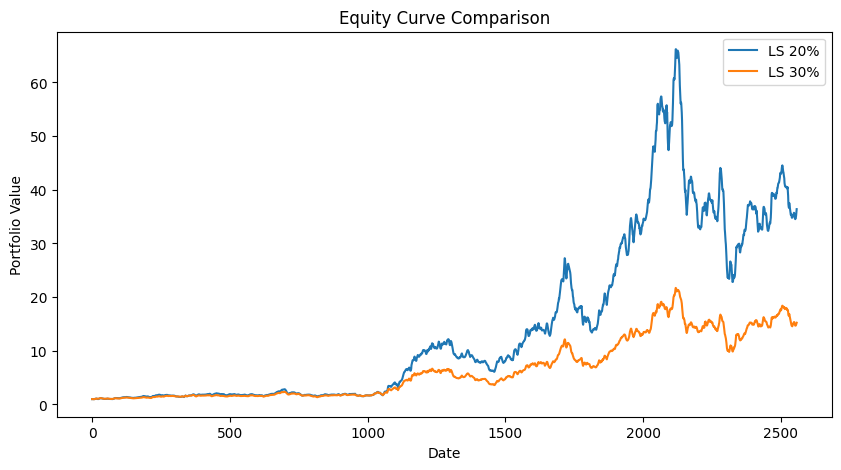

In [101]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

port_ls_20["equity_curve"].plot(label="LS 20%")
port_ls_30["equity_curve"].plot(label="LS 30%")

plt.title("Equity Curve Comparison")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()

plt.show()

The 20% long-short portfolio maximizes alpha and delivers superior growth, while the 30% portfolio provides a smoother equity curve with improved drawdown control, highlighting a clear trade-off between return and stability.

**Volatiity scaling 20% Decile**

In [102]:
[c for c in df_combined.columns if "vol" in c.lower() or "exp" in c.lower() or "high" in c.lower()]

['exposure_lag1',
 'exp_linear_lag1',
 'exp_sqrt_lag1',
 'exp_floor_30_lag1',
 'exp_threshold_lag1',
 'signal_vol_adj',
 'signal_vol_adj_hybrid',
 'exp_pow_0_3_lag1',
 'exp_pow_0_5_lag1',
 'exp_pow_0_7_lag1',
 'exp_pow_1_0_lag1',
 'exp_pow_1_2_lag1',
 'vol_adj_pow_07_lag1',
 'exp_pow_07_lag1',
 'vol_20',
 'inv_vol',
 'vol_rank',
 'dynamic_cap_vol']

In [103]:
weights_ls_20_vol = weights_ls_20.copy()

date_exposure = (df_combined[["Date", "exp_pow_07_lag1"]]
                 .drop_duplicates()
                 .sort_values("Date")
)

weights_ls_20_vol = weights_ls_20_vol.merge(
    date_exposure,
    on="Date",
    how="left"
)

weights_ls_20_vol["weight"] = (
    weights_ls_20_vol["weight"] * weights_ls_20_vol["exp_pow_07_lag1"]
)


In [104]:
print(weights_ls_20_vol.columns)
print(weights_ls_20_vol["exp_pow_07_lag1"].isna().sum())
print(weights_ls_20_vol[["Date", "Ticker", "weight", "exp_pow_07_lag1"]].head())

Index(['Date', 'Ticker', 'weight', 'exp_pow_07_lag1'], dtype='str')
3000
        Date Ticker   weight  exp_pow_07_lag1
0 2016-01-04   AAPL  0.00000          0.89964
1 2016-01-04   AMZN  0.09996          0.89964
2 2016-01-04    BAC  0.00000          0.89964
3 2016-01-04   COST  0.09996          0.89964
4 2016-01-04    CVX  0.00000          0.89964


In [105]:
port_ls_20_vol = backtest_cross_sectional_strategy(
    weights_ls_20_vol,
    df_combined,
    return_col="fwd_ret_5"
)

print("LS 20% + Vol Overlay Sharpe:", sharpe_ratio(port_ls_20_vol["portfolio_return"]))
print("LS 20% + Vol Overlay MDD:", max_drawdown(port_ls_20_vol["equity_curve"]))
print("LS 20% + Vol Overlay CAGR:", compute_cagr(port_ls_20_vol["equity_curve"]))
print("LS 20% + Vol Overlay Vol:", annual_vol(port_ls_20_vol["portfolio_return"]))
print("LS 20% + Vol Overlay Calmar:", calmar_ratio(port_ls_20_vol["equity_curve"]))

LS 20% + Vol Overlay Sharpe: 1.4575369553914475
LS 20% + Vol Overlay MDD: -0.6242737681674821
LS 20% + Vol Overlay CAGR: 0.3241551076932738
LS 20% + Vol Overlay Vol: 0.20757929395500196
LS 20% + Vol Overlay Calmar: 0.5192515274905937


Applying a volatility-based exposure (exp_pow_lag1) overlay reduces drawdown and volatility, but significantly dampens returns, indicating that the current scaling function is overly aggressive for the strength of the underlying signal. Hence require to test exp_linear_lag1 and exp_sqrt_lag1

**With exp_linear_lag1**

In [106]:
weights_ls_20_linear_lag1_vol = weights_ls_20.copy()

date_exposure_linear = (df_combined[["Date", "exp_linear_lag1"]]
                 .drop_duplicates()
                 .sort_values("Date")
)

weights_ls_20_linear_lag1_vol = weights_ls_20_linear_lag1_vol.merge(
    date_exposure_linear,
    on="Date",
    how="left"
)

weights_ls_20_linear_lag1_vol["weight"] = (
    weights_ls_20_linear_lag1_vol["weight"] * weights_ls_20_linear_lag1_vol["exp_linear_lag1"]
)

In [107]:
print(weights_ls_20_linear_lag1_vol.columns)
print(weights_ls_20_linear_lag1_vol["exp_linear_lag1"].isna().sum())
print(weights_ls_20_linear_lag1_vol[["Date", "Ticker", "weight", "exp_linear_lag1"]].head())

Index(['Date', 'Ticker', 'weight', 'exp_linear_lag1'], dtype='str')
3000
        Date Ticker   weight  exp_linear_lag1
0 2016-01-04   AAPL  0.00000         0.859773
1 2016-01-04   AMZN  0.09553         0.859773
2 2016-01-04    BAC  0.00000         0.859773
3 2016-01-04   COST  0.09553         0.859773
4 2016-01-04    CVX  0.00000         0.859773


In [108]:
port_ls_20_linear_lag1_vol = backtest_cross_sectional_strategy(
    weights_ls_20_linear_lag1_vol,
    df_combined,
    return_col="fwd_ret_5"
)

print("LS 20% + Linear Lag1 Vol Sharpe:", sharpe_ratio(port_ls_20_linear_lag1_vol["portfolio_return"]))
print("LS 20% + Linear Lag1 Vol MDD:", max_drawdown(port_ls_20_linear_lag1_vol["equity_curve"]))
print("LS 20% + Linear Lag1 Vol CAGR:", compute_cagr(port_ls_20_linear_lag1_vol["equity_curve"]))
print("LS 20% + Linear Lag1 Vol Vol:", annual_vol(port_ls_20_linear_lag1_vol["portfolio_return"]))
print("LS 20% + Linear Lag1 Vol Calmar:", calmar_ratio(port_ls_20_linear_lag1_vol["equity_curve"]))

LS 20% + Linear Lag1 Vol Sharpe: 1.4246133645507697
LS 20% + Linear Lag1 Vol MDD: -0.611030160035602
LS 20% + Linear Lag1 Vol CAGR: 0.29570137214909886
LS 20% + Linear Lag1 Vol Vol: 0.19539008007230677
LS 20% + Linear Lag1 Vol Calmar: 0.4839390777893348


Both power-based and linear volatility overlays successfully reduce drawdown and volatility, but overly suppress returns, indicating that full exposure scaling is too aggressive and requires partial application.

**With exp_sqt_lag1**

In [109]:
weights_ls_20_sqrt_lag1_vol = weights_ls_20.copy()

date_exposure_sqrt = (df_combined[["Date", "exp_sqrt_lag1"]]
                 .drop_duplicates()
                 .sort_values("Date")
)

weights_ls_20_sqrt_lag1_vol = weights_ls_20_sqrt_lag1_vol.merge(
    date_exposure_sqrt,
    on="Date",
    how="left"
)

weights_ls_20_sqrt_lag1_vol["weight"] = (
    weights_ls_20_sqrt_lag1_vol["weight"] * weights_ls_20_sqrt_lag1_vol["exp_sqrt_lag1"]
)

In [110]:
print(weights_ls_20_sqrt_lag1_vol.columns)
print(weights_ls_20_sqrt_lag1_vol["exp_sqrt_lag1"].isna().sum())
print(weights_ls_20_sqrt_lag1_vol[["Date", "Ticker", "weight", "exp_sqrt_lag1"]].head())

Index(['Date', 'Ticker', 'weight', 'exp_sqrt_lag1'], dtype='str')
3000
        Date Ticker    weight  exp_sqrt_lag1
0 2016-01-04   AAPL  0.000000        0.92724
1 2016-01-04   AMZN  0.103027        0.92724
2 2016-01-04    BAC  0.000000        0.92724
3 2016-01-04   COST  0.103027        0.92724
4 2016-01-04    CVX  0.000000        0.92724


In [111]:
port_ls_20_sqrt_lag1_vol = backtest_cross_sectional_strategy(
    weights_ls_20_sqrt_lag1_vol,
    df_combined,
    return_col="fwd_ret_5"
)

print("LS 20% + sqrt Lag1 Vol Sharpe:", sharpe_ratio(port_ls_20_sqrt_lag1_vol["portfolio_return"]))
print("LS 20% + sqrt Lag1 Vol MDD:", max_drawdown(port_ls_20_sqrt_lag1_vol["equity_curve"]))
print("LS 20% + sqrt Lag1 Vol CAGR:", compute_cagr(port_ls_20_sqrt_lag1_vol["equity_curve"]))
print("LS 20% + sqrt Lag1 Vol Vol:", annual_vol(port_ls_20_sqrt_lag1_vol["portfolio_return"]))
print("LS 20% + sqrt Lag1 Vol Calmar:", calmar_ratio(port_ls_20_sqrt_lag1_vol["equity_curve"]))

LS 20% + sqrt Lag1 Vol Sharpe: 1.4818213619001301
LS 20% + sqrt Lag1 Vol MDD: -0.633123356851607
LS 20% + sqrt Lag1 Vol CAGR: 0.34707943068535707
LS 20% + sqrt Lag1 Vol Vol: 0.21713939623710618
LS 20% + sqrt Lag1 Vol Calmar: 0.5482019055675218


Among the full volatility overlays, square-root scaling provides the best trade-off by preserving more of the decile portfolio’s alpha while still reducing drawdown and volatility, although the unscaled LS 20% strategy remains superior overall.

In [112]:
results = []


def add_result(name, port):
    results.append({
        "Strategy": name,
        "Sharpe": sharpe_ratio(port["portfolio_return"]),
        "MDD": max_drawdown(port["equity_curve"]),
        "CAGR": compute_cagr(port["equity_curve"]),
        "Vol": annual_vol(port["portfolio_return"]),
        "Calmar": calmar_ratio(port["equity_curve"])
    })

In [113]:
add_result("LS 20%", port_ls_20)
add_result("LS 30%", port_ls_30)

add_result("LS 20% + Pow 0.7", port_ls_20_vol)
add_result("LS 20% + Linear", port_ls_20_linear_lag1_vol)
add_result("LS 20% + Sqrt", port_ls_20_sqrt_lag1_vol)



In [114]:
results_df = pd.DataFrame(results)

results_df.sort_values(by="Sharpe", ascending=False)

results_df

,Strategy,Sharpe,MDD,CAGR,Vol,Calmar
0,LS 20%,1.515955,-0.655290,0.424730,0.255107,0.648155
1,LS 30%,1.417586,-0.548982,0.306984,0.204020,0.559189
2,LS 20% + Pow 0.7,1.457537,-0.624274,0.324155,0.207579,0.519252
3,LS 20% + Linear,1.424613,-0.611030,0.295701,0.195390,0.483939
4,LS 20% + Sqrt,1.481821,-0.633123,0.347079,0.217139,0.548202


**LS 20% with Partial Scaling**

In [115]:
weights_ls_20_sqrt_partial = weights_ls_20.copy()

date_exposure_sqrt = (
    df_combined[["Date", "exp_sqrt_lag1"]]
    .drop_duplicates()
    .sort_values("Date")
)

weights_ls_20_sqrt_partial = weights_ls_20_sqrt_partial.merge(
    date_exposure_sqrt,
    on="Date",
    how="left"
)

weights_ls_20_sqrt_partial["weight"] = (
    weights_ls_20_sqrt_partial["weight"] * (0.5 + 0.5 * weights_ls_20_sqrt_partial["exp_sqrt_lag1"])
)

In [116]:
port_ls_20_sqrt_partial = backtest_cross_sectional_strategy(
    weights_ls_20_sqrt_partial,
    df_combined,
    return_col="fwd_ret_5"
)

add_result("LS 20% + Sqrt Partial", port_ls_20_sqrt_partial)

In [117]:
print("LS 20% + sqrt Partial Sharpe:", sharpe_ratio(port_ls_20_sqrt_partial["portfolio_return"]))
print("LS 20% + sqrt Partial MDD:", max_drawdown(port_ls_20_sqrt_partial["equity_curve"]))
print("LS 20% + sqrt Partial CAGR:", compute_cagr(port_ls_20_sqrt_partial["equity_curve"]))
print("LS 20% + sqrt Partial Vol:", annual_vol(port_ls_20_sqrt_partial["portfolio_return"]))
print("LS 20% + sqrt Partial Calmar:", calmar_ratio(port_ls_20_sqrt_partial["equity_curve"]))

LS 20% + sqrt Partial Sharpe: 1.520347666596827
LS 20% + sqrt Partial MDD: -0.6443734613769128
LS 20% + sqrt Partial CAGR: 0.38643401197200467
LS 20% + sqrt Partial Vol: 0.2329122955662177
LS 20% + sqrt Partial Calmar: 0.5997050392892704


In [118]:
results_df = pd.DataFrame(results)

results_df.sort_values(by="Sharpe", ascending=False)

results_df

,Strategy,Sharpe,MDD,CAGR,Vol,Calmar
0,LS 20%,1.515955,-0.655290,0.424730,0.255107,0.648155
1,LS 30%,1.417586,-0.548982,0.306984,0.204020,0.559189
2,LS 20% + Pow 0.7,1.457537,-0.624274,0.324155,0.207579,0.519252
3,LS 20% + Linear,1.424613,-0.611030,0.295701,0.195390,0.483939
4,LS 20% + Sqrt,1.481821,-0.633123,0.347079,0.217139,0.548202
5,LS 20% + Sqrt Partial,1.520348,-0.644373,0.386434,0.232912,0.599705


**Normalising Exposure**

In [119]:
weights_ls_20_sqrt_partial_norm = weights_ls_20_sqrt_partial.copy()
weights_ls_20_sqrt_partial_norm["abs_weight"] = weights_ls_20_sqrt_partial_norm["weight"].abs()

gross_by_date = weights_ls_20_sqrt_partial_norm.groupby("Date")["abs_weight"].transform("sum")

weights_ls_20_sqrt_partial_norm["weight"] = (
    weights_ls_20_sqrt_partial_norm["weight"] / gross_by_date
)

In [120]:
port_ls_20_sqrt_partial_normalized = backtest_cross_sectional_strategy(
    weights_ls_20_sqrt_partial_norm[["Date", "Ticker", "weight"]],
    df_combined,
    return_col="fwd_ret_5"
)

add_result("LS 20% + Sqrt Partial normalized", port_ls_20_sqrt_partial_normalized)

In [121]:
results_df = pd.DataFrame(results)

results_df.sort_values(by="Sharpe", ascending=False).drop_duplicates()

results_df

,Strategy,Sharpe,MDD,CAGR,Vol,Calmar
0,LS 20%,1.515955,-0.655290,0.424730,0.255107,0.648155
1,LS 30%,1.417586,-0.548982,0.306984,0.204020,0.559189
2,LS 20% + Pow 0.7,1.457537,-0.624274,0.324155,0.207579,0.519252
3,LS 20% + Linear,1.424613,-0.611030,0.295701,0.195390,0.483939
4,LS 20% + Sqrt,1.481821,-0.633123,0.347079,0.217139,0.548202
5,LS 20% + Sqrt Partial,1.520348,-0.644373,0.386434,0.232912,0.599705
6,LS 20% + Sqrt Partial normalized,1.544191,-0.655290,0.426073,0.250263,0.650205


The normalized result is almost the same as raw Ls 20% because every weight on that date was multiplied by the same scalar ( partial vol oerlay is a date level scalar ie, weight_new = weight_old * scalar_t), then the normalization basically cancels the scaling.

In [122]:
weights_ls_20_sqrt_partial_norm.groupby("Date")["weight"].apply(lambda x: x.abs().sum()).head()

Date
2016-01-04    1.0
2016-01-05    1.0
2016-01-06    1.0
2016-01-07    1.0
2016-01-08    1.0
Name: weight, dtype: float64

In [123]:
weights_ls_20_sqrt_partial_norm.groupby("Date")["weight"].apply(lambda x: x.abs().sum()).head()

Date
2016-01-04    1.0
2016-01-05    1.0
2016-01-06    1.0
2016-01-07    1.0
2016-01-08    1.0
Name: weight, dtype: float64

In [124]:
weights_ls_20_sqrt_partial_norm.groupby("Date")["weight"].sum().head()

Date
2016-01-04    0.111111
2016-01-05    0.111111
2016-01-06    0.111111
2016-01-07    0.111111
2016-01-08    0.111111
Name: weight, dtype: float64

Net exposure is not zero. it has a long bias. so benefits from market going up, suffers if market cradhes, MDD can still be high.

**Fixing the Net Exposure**

In [125]:
weights_ls_20_sqrt_partial_norm_neutralize = weights_ls_20_sqrt_partial_norm.copy()

weights_ls_20_sqrt_partial_norm_neutralize["weight"] = (
    weights_ls_20_sqrt_partial_norm_neutralize["weight"] - 
    weights_ls_20_sqrt_partial_norm_neutralize.groupby("Date")["weight"].transform("mean")
)


In [126]:
weights_ls_20_sqrt_partial_norm_neutralize["abs_weight"] = (
    weights_ls_20_sqrt_partial_norm_neutralize["weight"].abs()
)

gross_by_date = (
    weights_ls_20_sqrt_partial_norm_neutralize.groupby("Date")["abs_weight"].transform("sum")
)

weights_ls_20_sqrt_partial_norm_neutralize["weight"] = (
    weights_ls_20_sqrt_partial_norm_neutralize["weight"] / gross_by_date
)

In [127]:
port_ls_20_sqrt_partial_normalized_neutralize = backtest_cross_sectional_strategy(
    weights_ls_20_sqrt_partial_norm_neutralize[["Date", "Ticker", "weight"]],
    df_combined,
    return_col="fwd_ret_5"
)

add_result("LS 20% + Sqrt Partial normalized_neutralize", port_ls_20_sqrt_partial_normalized_neutralize)

In [128]:
results_df = pd.DataFrame(results)

results_df.sort_values(by="Sharpe", ascending=False).drop_duplicates()

results_df

,Strategy,Sharpe,MDD,CAGR,Vol,Calmar
0,LS 20%,1.515955,-0.655290,0.424730,0.255107,0.648155
1,LS 30%,1.417586,-0.548982,0.306984,0.204020,0.559189
2,LS 20% + Pow 0.7,1.457537,-0.624274,0.324155,0.207579,0.519252
3,LS 20% + Linear,1.424613,-0.611030,0.295701,0.195390,0.483939
4,LS 20% + Sqrt,1.481821,-0.633123,0.347079,0.217139,0.548202
5,LS 20% + Sqrt Partial,1.520348,-0.644373,0.386434,0.232912,0.599705
6,LS 20% + Sqrt Partial normalized,1.544191,-0.655290,0.426073,0.250263,0.650205
7,LS 20% + Sqrt Partial normalized_neutralize,1.097604,-0.645107,0.253414,0.230536,0.392824


Enforcing strict market neutrality significantly reduces returns, revealing that the strategy’s performance partly relies on directional exposure (your portfolio makes or loses money depending on the overall market direction), and that drawdown reduction must instead be addressed through portfolio construction rather than removing beta.
(beta is how sensitive the portfolio is to the market, how much you portfolio moves when market moves)

**LS 30 SQRT Partial Normalized**

In [129]:
weights_ls_30_sqrt_partial = weights_ls_30.copy()

date_exposure_sqrt = (
    df_combined[["Date", "exp_sqrt_lag1"]]
    .drop_duplicates()
    .sort_values("Date")
)

weights_ls_30_sqrt_partial = weights_ls_30_sqrt_partial.merge(
    date_exposure_sqrt,
    on="Date",
    how="left"
)

weights_ls_30_sqrt_partial["weight"] = (
    weights_ls_30_sqrt_partial["weight"] *
    (0.5 + 0.5 * weights_ls_30_sqrt_partial["exp_sqrt_lag1"])
)

In [130]:
weights_ls_30_sqrt_partial_norm = weights_ls_30_sqrt_partial.copy()

weights_ls_30_sqrt_partial_norm["abs_weight"] = (
    weights_ls_30_sqrt_partial_norm["weight"].abs()
)

gross = (
    weights_ls_30_sqrt_partial_norm.groupby("Date")["abs_weight"].transform("sum")
)

weights_ls_30_sqrt_partial_norm["weight"] = (
    weights_ls_30_sqrt_partial_norm["weight"] / gross
)

In [131]:
port_ls_30_sqrt_partial_norm = backtest_cross_sectional_strategy(
    weights_ls_30_sqrt_partial_norm[["Date", "Ticker", "weight"]],
    df_combined,
    return_col="fwd_ret_5"
)

add_result("LS 30% + Sqrt Partial norm", port_ls_30_sqrt_partial_norm)

In [132]:
weights_ls_30_sqrt_partial_norm_neut = weights_ls_30_sqrt_partial_norm.copy()

weights_ls_30_sqrt_partial_norm_neut["weight"] = (
    weights_ls_30_sqrt_partial_norm_neut["weight"] -
    weights_ls_30_sqrt_partial_norm_neut.groupby("Date")["weight"].transform("mean")
)

# re-normalize after neutralization
weights_ls_30_sqrt_partial_norm_neut["abs_weight"] = (
    weights_ls_30_sqrt_partial_norm_neut["weight"].abs()
)

gross = (
    weights_ls_30_sqrt_partial_norm_neut.groupby("Date")["abs_weight"].transform("sum")
)

weights_ls_30_sqrt_partial_norm_neut["weight"] = (
    weights_ls_30_sqrt_partial_norm_neut["weight"] / gross
)

port_ls_30_sqrt_partial_norm_neut = backtest_cross_sectional_strategy(
    weights_ls_30_sqrt_partial_norm_neut[["Date", "Ticker", "weight"]],
    df_combined,
    return_col="fwd_ret_5"
)

add_result("LS 30% + Sqrt Partial norm + neut", port_ls_30_sqrt_partial_norm_neut)

In [133]:
results_df = pd.DataFrame(results)

results_df.sort_values(by="Sharpe", ascending=False).drop_duplicates()

results_df

,Strategy,Sharpe,MDD,CAGR,Vol,Calmar
0,LS 20%,1.515955,-0.655290,0.424730,0.255107,0.648155
1,LS 30%,1.417586,-0.548982,0.306984,0.204020,0.559189
2,LS 20% + Pow 0.7,1.457537,-0.624274,0.324155,0.207579,0.519252
3,LS 20% + Linear,1.424613,-0.611030,0.295701,0.195390,0.483939
4,LS 20% + Sqrt,1.481821,-0.633123,0.347079,0.217139,0.548202
5,LS 20% + Sqrt Partial,1.520348,-0.644373,0.386434,0.232912,0.599705
6,LS 20% + Sqrt Partial normalized,1.544191,-0.655290,0.426073,0.250263,0.650205
7,LS 20% + Sqrt Partial normalized_neutralize,1.097604,-0.645107,0.253414,0.230536,0.392824
8,LS 30% + Sqrt Partial norm,1.450600,-0.548982,0.308863,0.199778,0.562610
9,LS 30% + Sqrt Partial norm + neut,1.060113,-0.557512,0.201173,0.191010,0.360841


**Blending LS 20 & Ls 30**

In [138]:
# --- Helper: build equity curve from a return series ---
def equity_from_returns(ret_series, start=1.0):
    return start * (1 + ret_series.fillna(0)).cumprod()


# --- Helper: add result from a return series directly ---
def add_result_from_returns(name, ret_series):
    equity_curve = equity_from_returns(ret_series)

    results.append({
        "Strategy": name,
        "Sharpe": sharpe_ratio(ret_series),
        "MDD": max_drawdown(equity_curve),
        "CAGR": compute_cagr(equity_curve),
        "Vol": annual_vol(ret_series),
        "Calmar": calmar_ratio(equity_curve),
    })


# --- Build blend return series ---
blend_50_50_ret = (
    0.5 * port_ls_20["portfolio_return"] +
    0.5 * port_ls_30["portfolio_return"]
)

blend_60_40_ret = (
    0.6 * port_ls_20["portfolio_return"] +
    0.4 * port_ls_30["portfolio_return"]
)

blend_70_30_ret = (
    0.7 * port_ls_20["portfolio_return"] +
    0.3 * port_ls_30["portfolio_return"]
)

blend_40_60_ret = (
    0.4 * port_ls_20["portfolio_return"] +
    0.6 * port_ls_30["portfolio_return"]
)


# --- Add to results table ---
add_result_from_returns("Blend 50/50 (LS20 + LS30)", blend_50_50_ret)
add_result_from_returns("Blend 60/40 (LS20 + LS30)", blend_60_40_ret)
add_result_from_returns("Blend 70/30 (LS20 + LS30)", blend_70_30_ret)
add_result_from_returns("Blend 40/60 (LS20 + LS30)", blend_40_60_ret)


# --- View updated comparison table ---
results_df = pd.DataFrame(results).drop_duplicates(subset=["Strategy"]).round(3)
results_df = results_df.sort_values(by="Sharpe", ascending=False)
results_df

,Strategy,Sharpe,MDD,CAGR,Vol,Calmar
6,LS 20% + Sqrt Partial normalized,1.544,-0.655,0.426,0.250,0.650
5,LS 20% + Sqrt Partial,1.520,-0.644,0.386,0.233,0.600
0,LS 20%,1.516,-0.655,0.425,0.255,0.648
12,Blend 70/30 (LS20 + LS30),1.515,-0.625,0.390,0.236,0.624
11,Blend 60/40 (LS20 + LS30),1.510,-0.614,0.378,0.230,0.616
10,Blend 50/50 (LS20 + LS30),1.503,-0.604,0.366,0.225,0.607
13,Blend 40/60 (LS20 + LS30),1.493,-0.593,0.355,0.220,0.599
4,LS 20% + Sqrt,1.482,-0.633,0.347,0.217,0.548
2,LS 20% + Pow 0.7,1.458,-0.624,0.324,0.208,0.519
8,LS 30% + Sqrt Partial norm,1.451,-0.549,0.309,0.200,0.563


**Volatility Targeting**

In [139]:
target_vol = 0.15

ret = blend_60_40_ret.copy()

rolling_vol = ret.rolling(20).std() * np.sqrt(252)

scaling = target_vol / rolling_vol
scaling = scaling.clip(upper=2.0)

ret_vol_targeted = ret * scaling.shift(1)

add_result_from_returns("Blend 60/40 + Vol Target", ret_vol_targeted)

In [140]:
results_df = pd.DataFrame(results).drop_duplicates(subset=["Strategy"]).round(3)
results_df = results_df.sort_values(by="Sharpe", ascending=False)
results_df

,Strategy,Sharpe,MDD,CAGR,Vol,Calmar
6,LS 20% + Sqrt Partial normalized,1.544,-0.655,0.426,0.250,0.650
5,LS 20% + Sqrt Partial,1.520,-0.644,0.386,0.233,0.600
0,LS 20%,1.516,-0.655,0.425,0.255,0.648
12,Blend 70/30 (LS20 + LS30),1.515,-0.625,0.390,0.236,0.624
11,Blend 60/40 (LS20 + LS30),1.510,-0.614,0.378,0.230,0.616
10,Blend 50/50 (LS20 + LS30),1.503,-0.604,0.366,0.225,0.607
13,Blend 40/60 (LS20 + LS30),1.493,-0.593,0.355,0.220,0.599
4,LS 20% + Sqrt,1.482,-0.633,0.347,0.217,0.548
2,LS 20% + Pow 0.7,1.458,-0.624,0.324,0.208,0.519
8,LS 30% + Sqrt Partial norm,1.451,-0.549,0.309,0.200,0.563


**Sweeping Target Volatility**

In [141]:
for tv in [0.15, 0.18, 0.20, 0.25]:
    rolling_vol = blend_60_40_ret.rolling(20).std() * np.sqrt(252)
    scaling = tv / rolling_vol
    scaling = scaling.clip(upper=2.0)

    ret_scaled = blend_60_40_ret * scaling.shift(1)

    add_result_from_returns(f"Blend 60/40 + Vol Target {tv}", ret_scaled)

In [142]:
results_df = pd.DataFrame(results).drop_duplicates(subset=["Strategy"]).round(3)
results_df = results_df.sort_values(by="Sharpe", ascending=False)
results_df

,Strategy,Sharpe,MDD,CAGR,Vol,Calmar
6,LS 20% + Sqrt Partial normalized,1.544,-0.655,0.426,0.250,0.650
5,LS 20% + Sqrt Partial,1.520,-0.644,0.386,0.233,0.600
0,LS 20%,1.516,-0.655,0.425,0.255,0.648
12,Blend 70/30 (LS20 + LS30),1.515,-0.625,0.390,0.236,0.624
11,Blend 60/40 (LS20 + LS30),1.510,-0.614,0.378,0.230,0.616
10,Blend 50/50 (LS20 + LS30),1.503,-0.604,0.366,0.225,0.607
13,Blend 40/60 (LS20 + LS30),1.493,-0.593,0.355,0.220,0.599
4,LS 20% + Sqrt,1.482,-0.633,0.347,0.217,0.548
2,LS 20% + Pow 0.7,1.458,-0.624,0.324,0.208,0.519
8,LS 30% + Sqrt Partial norm,1.451,-0.549,0.309,0.200,0.563


This project developed a cross-sectional long/short equity strategy based on machine learning return forecasts and evaluated multiple portfolio construction and risk management techniques to improve its real-world applicability. The initial concentrated strategy (LS 20%) demonstrated strong predictive power with high Sharpe and CAGR, but suffered from substantial drawdowns, indicating that while the signal contained meaningful alpha, it was highly volatile. Expanding the portfolio to a broader selection (LS 30%) improved stability by reducing drawdown and volatility, albeit at the cost of lower returns, highlighting the trade-off between concentration and diversification. Combining these two approaches through a weighted blend (60% LS 20%, 40% LS 30%) proved to be the most effective structural improvement, preserving most of the alpha while achieving a more balanced risk-return profile.

Further experiments with volatility-based weight scaling showed limited impact, as these adjustments were largely neutralized by portfolio normalization and did not meaningfully change overall exposure. In contrast, applying portfolio-level volatility targeting successfully reduced drawdowns by dynamically adjusting exposure over time; however, aggressive targets significantly suppressed returns and reduced overall efficiency, making them less desirable in this context. Similarly, enforcing strict market neutrality by removing net exposure reduced performance considerably, revealing that part of the strategy’s returns are driven by directional market exposure (beta) rather than purely cross-sectional alpha.

Overall, the findings suggest that the most effective improvements came from portfolio construction choices—specifically diversification and blending—rather than aggressive risk overlays or constraints. The final outcome is a dual-strategy framework consisting of a high-performing blended portfolio (LS 20/30) as the primary alpha driver, alongside a more stable LS 30% strategy that can act as a defensive component. This structure provides flexibility in managing the trade-off between return and drawdown, and forms a solid foundation for further enhancements such as position sizing, turnover control, or regime-based allocation.